# AP2 - Processamento de Linguagem Natural (NLP)
## Pipeline Coerente de Classificação Multiclasse de Emoções em Texto

Este notebook apresenta o desenvolvimento de um pipeline completo de Processamento de Linguagem Natural para classificar sentimentos em nível de emoções a partir de textos curtos (tweets e postagens em redes sociais). O dataset utilizado é o **`dair-ai/emotion`** (Hugging Face), que contém textos rotulados com 6 emoções humanas fundamentais:
*   `sadness` (tristeza)
*   `joy` (alegria)
*   `love` (amor)
*   `anger` (raiva)
*   `fear` (medo)
*   `surprise` (surpresa)

---

### Objetivos do Trabalho
1.  **Exploração Detalhada (EDA):** Analisar a consistência das repartições, tamanhos de textos por classe e os termos semanticamente associados a cada sentimento.
2.  **Modelo Baseline:** Desenvolver uma solução clássica e interpretável combinando representações vetoriais baseadas em frequência (**TF-IDF**) e um classificador linear (**Regressão Logística**).
3.  **Modelo de Deep Learning:** Realizar o ajuste fino (*fine-tuning*) de um modelo de linguagem pré-treinado (**DistilBERT**) da Hugging Face, implementando estratégias para lidar com desbalanceamento de classes (Weighted Cross-Entropy Loss) e evitar overfitting (Early Stopping).
4.  **Experimento Opcional Avançado:** Implementar o fine-tuning de um Transformer mais encorpado (**RoBERTa-base**) para análise de robustez e comparação de arquiteturas.
5.  **Análise Comparativa e Diagnóstico:** Comparar os modelos por meio de métricas quantitativas e realizar uma análise de erros profunda, identificando ambiguidades semânticas e casos de alta confiança incorretos.

---

### Estrutura do Pipeline
1.  **Configuração e Reprodutibilidade:** Verificação do ambiente (GPU CUDA) e fixação de sementes globais.
2.  **Carregamento dos Dados:** Acesso ao Hugging Face Datasets e mapeamento de IDs para nomes textuais.
3.  **Análise Exploratória Aprofundada (EDA):**
    *   Frequência das classes nos três splits (estratificação).
    *   Comprimento de sentenças (palavras/caracteres) por emoção.
    *   N-gramas (unigramas) mais frequentes de cada classe.
4.  **Definição das Métricas de Avaliação:** Explicação sobre F1-Macro e F1-Weighted.
5.  **Modelo Baseline (TF-IDF + Regressão Logística):**
    *   Pipeline de processamento de texto.
    *   Treinamento e métricas.
    *   Importância de características (Explicabilidade).
6.  **Modelo Transformer Principal (DistilBERT):**
    *   Tokenização por subpalavras.
    *   Cálculo de pesos de classe para Weighted Cross-Entropy.
    *   Configuração do Treinador (Trainer) com Early Stopping.
    *   Execução do fine-tuning.
7.  **Experimento Avançado Condicional (RoBERTa-base).**
8.  **Comparação dos Resultados e Discussão.**
9.  **Análise Qualitativa de Erros (Error Analysis):**
    *   Matrizes de confusão absoluta e normalizada.
    *   Investigação de erros de alta confiança.
10. **Inferência e Visualização de Probabilidades:**
    *   Previsão em novas frases com gráficos de barra estilizados.
    *   **Diagnóstico Qualitativo com Sarcasmo.**
11. **Salvamento dos Modelos e Resultados.**
12. **Conclusões e Discussão Teórica.**


## 1. Configuração do ambiente e Reprodutibilidade

Esta seção importa as bibliotecas principais, define uma semente global de reprodutibilidade e verifica a disponibilidade de aceleração de hardware (GPU NVIDIA via CUDA).


In [25]:
# Instalação das bibliotecas necessárias no ambiente do Colab ou local.
# Se executar localmente e já as tiver instaladas, esta célula pode ser pulada.
# Para GPUs NVIDIA de última geração RTX 50 (arquitetura Blackwell), use cu128 para suporte a sm_120:
# %pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
# %pip install -U datasets transformers accelerate scikit-learn pandas numpy matplotlib seaborn


In [26]:
# Evita a criação de widgets interativos do tqdm que quebram o leitor do GitHub
import tqdm
import tqdm.auto
tqdm.auto.tqdm = tqdm.tqdm

# Importações gerais da biblioteca padrão
import os
import json
import random
import warnings
from pathlib import Path
from collections import Counter

# Ciência de dados e visualização
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e modelos clássicos
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)
from sklearn.pipeline import Pipeline

# PyTorch e ecossistema Hugging Face
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

# Configurações estéticas dos gráficos para alta resolução
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.titlesize": 16,
    "legend.fontsize": 11
})

# Silenciar avisos redundantes
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Definição de sementes para reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Detecção de hardware (GPU acelerada por CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Versão do PyTorch: {torch.__version__}")
print(f"CUDA ativo na máquina: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU detectada: {torch.cuda.get_device_name(0)}")
else:
    print("Atenção: Nenhuma GPU CUDA detectada. O treinamento de Transformers na CPU será significativamente lento.")
    
print(f"Dispositivo padrão em uso: {device}")


Versão do PyTorch: 2.6.0+cu124
CUDA ativo na máquina: True
GPU detectada: NVIDIA GeForce RTX 3060 Laptop GPU
Dispositivo padrão em uso: cuda


## 2. Carregamento e Preparação do Dataset

O dataset `dair-ai/emotion` é amplamente utilizado como benchmark em NLP. Ele consiste em textos em inglês contendo expressões curtas rotuladas individualmente por anotadores humanos com base nas 6 emoções primárias. O Hugging Face Datasets organiza este corpus de forma estruturada nas três divisões clássicas de aprendizado supervisionado: treino (*train*), validação (*validation*) e teste (*test*).


In [27]:
# Carregamento do dataset a partir do repositório da Hugging Face
raw_datasets = load_dataset("dair-ai/emotion")
raw_datasets


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [28]:
# Exibição do tamanho de cada partição
for split_name, split_data in raw_datasets.items():
    print(f"Partição '{split_name}': {len(split_data)} amostras")

# Mapeamentos entre IDs numéricos e os rótulos originais das classes
label_feature = raw_datasets["train"].features["label"]
id2label = {i: name for i, name in enumerate(label_feature.names)}
label2id = {name: i for i, name in id2label.items()}

print("\nMapeamento de IDs para rótulos textuais:")
for idx, label_name in id2label.items():
    print(f"ID {idx} -> {label_name.upper()}")


Partição 'train': 16000 amostras
Partição 'validation': 2000 amostras
Partição 'test': 2000 amostras

Mapeamento de IDs para rótulos textuais:
ID 0 -> SADNESS
ID 1 -> JOY
ID 2 -> LOVE
ID 3 -> ANGER
ID 4 -> FEAR
ID 5 -> SURPRISE


In [29]:
# Conversão do topo do conjunto de treino para DataFrame para fins de inspeção e visualização rápida
exemplos_df = pd.DataFrame(raw_datasets["train"][:10])
exemplos_df["emotion"] = exemplos_df["label"].map(id2label)
exemplos_df[["text", "label", "emotion"]]


,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger
5,ive been feeling a little burdened lately wasn...,0,sadness
6,ive been taking or milligrams or times recomme...,5,surprise
7,i feel as confused about life as a teenager or...,4,fear
8,i have been with petronas for years i feel tha...,1,joy
9,i feel romantic too,2,love


## 3. Análise Exploratória de Dados (EDA) Aprofundada

Antes de aplicar qualquer algoritmo de NLP, é fundamental realizar uma Análise Exploratória completa para compreender as propriedades estatísticas do corpus. Investigaremos três pontos essenciais:
1.  **Distribuição de Classes nas Três Partições:** Permite verificar a presença de desbalanceamento de classes e garantir que a divisão do dataset manteve a mesma proporção em treino, validação e teste (estratificação ideal).
2.  **Distribuição do Comprimento dos Textos por Emoção:** Avalia se o tamanho das postagens (número de caracteres e de palavras) difere sistematicamente entre as emoções, o que poderia se tornar um viés espúrio para os modelos.
3.  **Análise de Unigramas Frequentes por Emoção (Sem Stopwords):** Revela os padrões lexicais e palavras-chave que definem semanticamente cada uma das emoções no corpus de treino.


Frequência relativa das emoções por split (%) :


,Treino,Validação,Teste
emotion,,,
joy,33.51,35.20,34.75
sadness,29.16,27.50,29.05
anger,13.49,13.75,13.75
fear,12.11,10.60,11.20
love,8.15,8.90,7.95
surprise,3.58,4.05,3.30


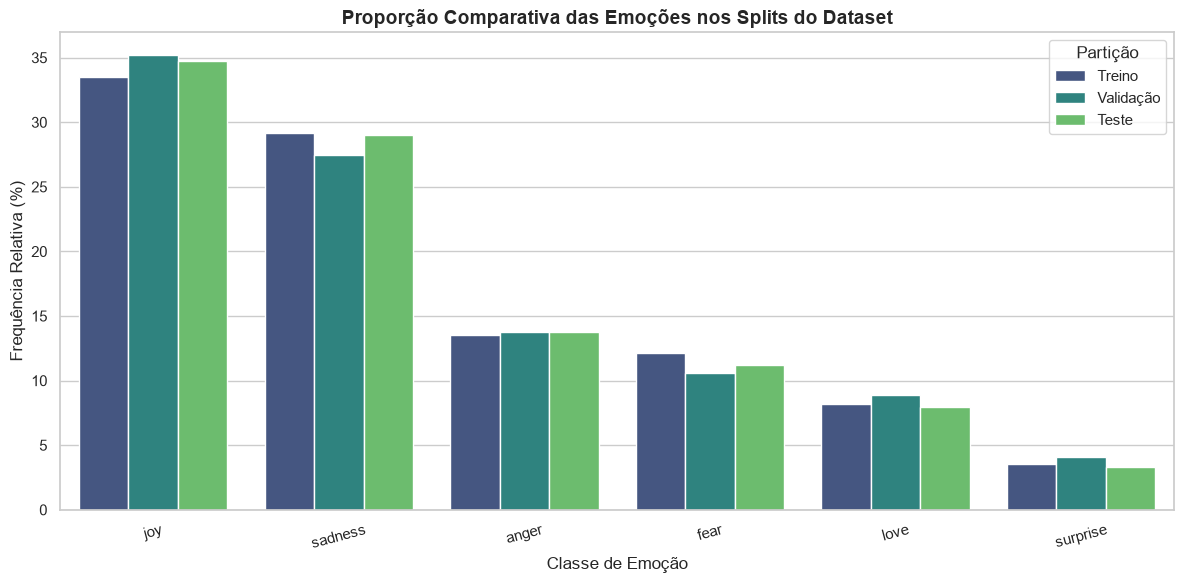

In [30]:
# Conversão dos splits para DataFrames pandas locais
train_df = pd.DataFrame(raw_datasets["train"])
train_df["emotion"] = train_df["label"].map(id2label)

val_df = pd.DataFrame(raw_datasets["validation"])
val_df["emotion"] = val_df["label"].map(id2label)

test_df = pd.DataFrame(raw_datasets["test"])
test_df["emotion"] = test_df["label"].map(id2label)

# Cálculo da distribuição de classes (%)
train_dist = train_df["emotion"].value_counts(normalize=True).rename("Treino")
val_dist = val_df["emotion"].value_counts(normalize=True).rename("Validação")
test_dist = test_df["emotion"].value_counts(normalize=True).rename("Teste")

dist_df = pd.concat([train_dist, val_dist, test_dist], axis=1) * 100
print("Frequência relativa das emoções por split (%) :")
display(dist_df.round(2))

# Plotagem lado a lado das proporções relativas
dist_melted = dist_df.reset_index().melt(id_vars="emotion", var_name="Partição", value_name="Porcentagem")
plt.figure(figsize=(12, 6))
sns.barplot(data=dist_melted, x="emotion", y="Porcentagem", hue="Partição", palette="viridis")
plt.title("Proporção Comparativa das Emoções nos Splits do Dataset", fontsize=14, fontweight="bold")
plt.xlabel("Classe de Emoção")
plt.ylabel("Frequência Relativa (%)")
plt.xticks(rotation=15)
plt.legend(title="Partição")
plt.tight_layout()
plt.show()


Estatísticas descritivas básicas do tamanho dos textos (Conjunto de Treino):


,count,mean,std,min,25%,50%,75%,max
char_count,16000.0,96.845812,55.904953,7.0,53.0,86.0,129.0,300.0
word_count,16000.0,19.166313,10.986905,2.0,11.0,17.0,25.0,66.0


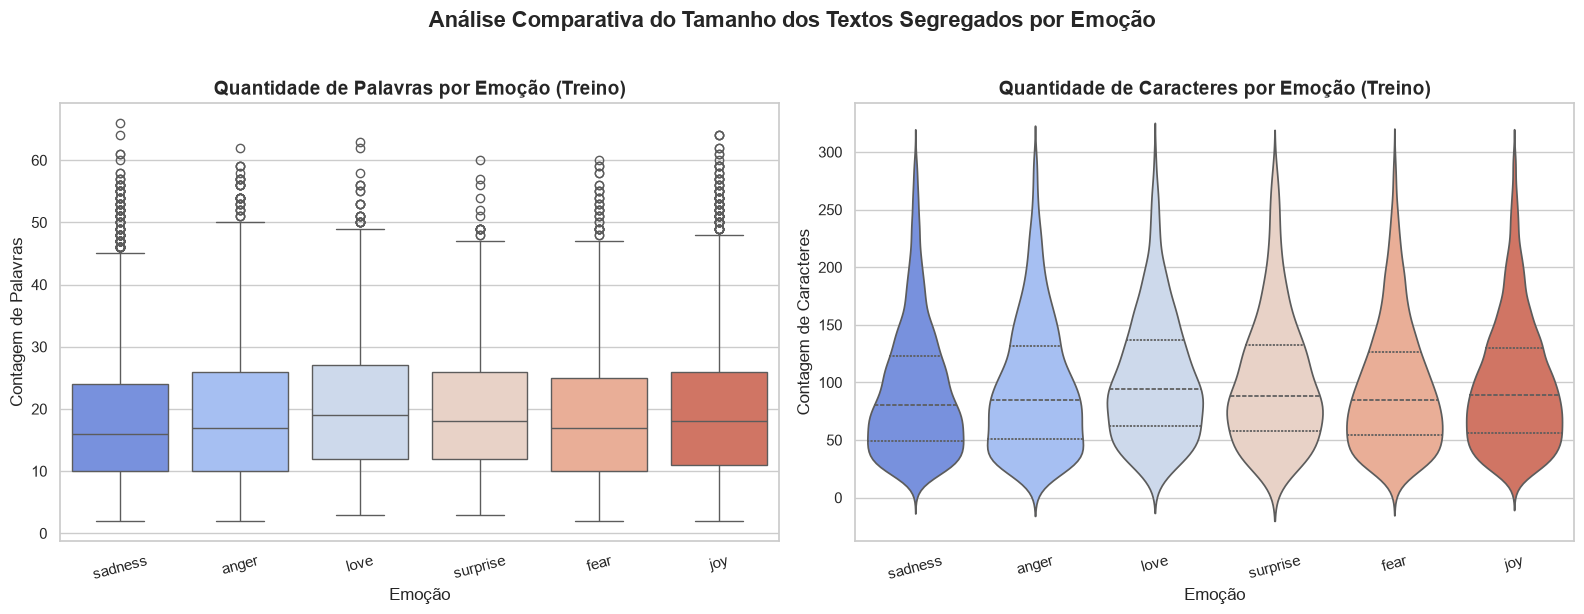

In [31]:
# Adicionar estatísticas de comprimento (caracteres e palavras)
for df_temp in [train_df, val_df, test_df]:
    df_temp["char_count"] = df_temp["text"].apply(len)
    df_temp["word_count"] = df_temp["text"].apply(lambda x: len(x.split()))

print("Estatísticas descritivas básicas do tamanho dos textos (Conjunto de Treino):")
display(train_df[["char_count", "word_count"]].describe().T)

# Visualização de distribuição por emoção
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot para número de palavras
sns.boxplot(data=train_df, x="emotion", y="word_count", hue="emotion", legend=False, ax=axes[0], palette="coolwarm")
axes[0].set_title("Quantidade de Palavras por Emoção (Treino)", fontweight="bold")
axes[0].set_xlabel("Emoção")
axes[0].set_ylabel("Contagem de Palavras")
axes[0].tick_params(axis='x', rotation=15)

# Violinplot para número de caracteres
sns.violinplot(data=train_df, x="emotion", y="char_count", hue="emotion", legend=False, ax=axes[1], palette="coolwarm", inner="quartile")
axes[1].set_title("Quantidade de Caracteres por Emoção (Treino)", fontweight="bold")
axes[1].set_xlabel("Emoção")
axes[1].set_ylabel("Contagem de Caracteres")
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle("Análise Comparativa do Tamanho dos Textos Segregados por Emoção", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


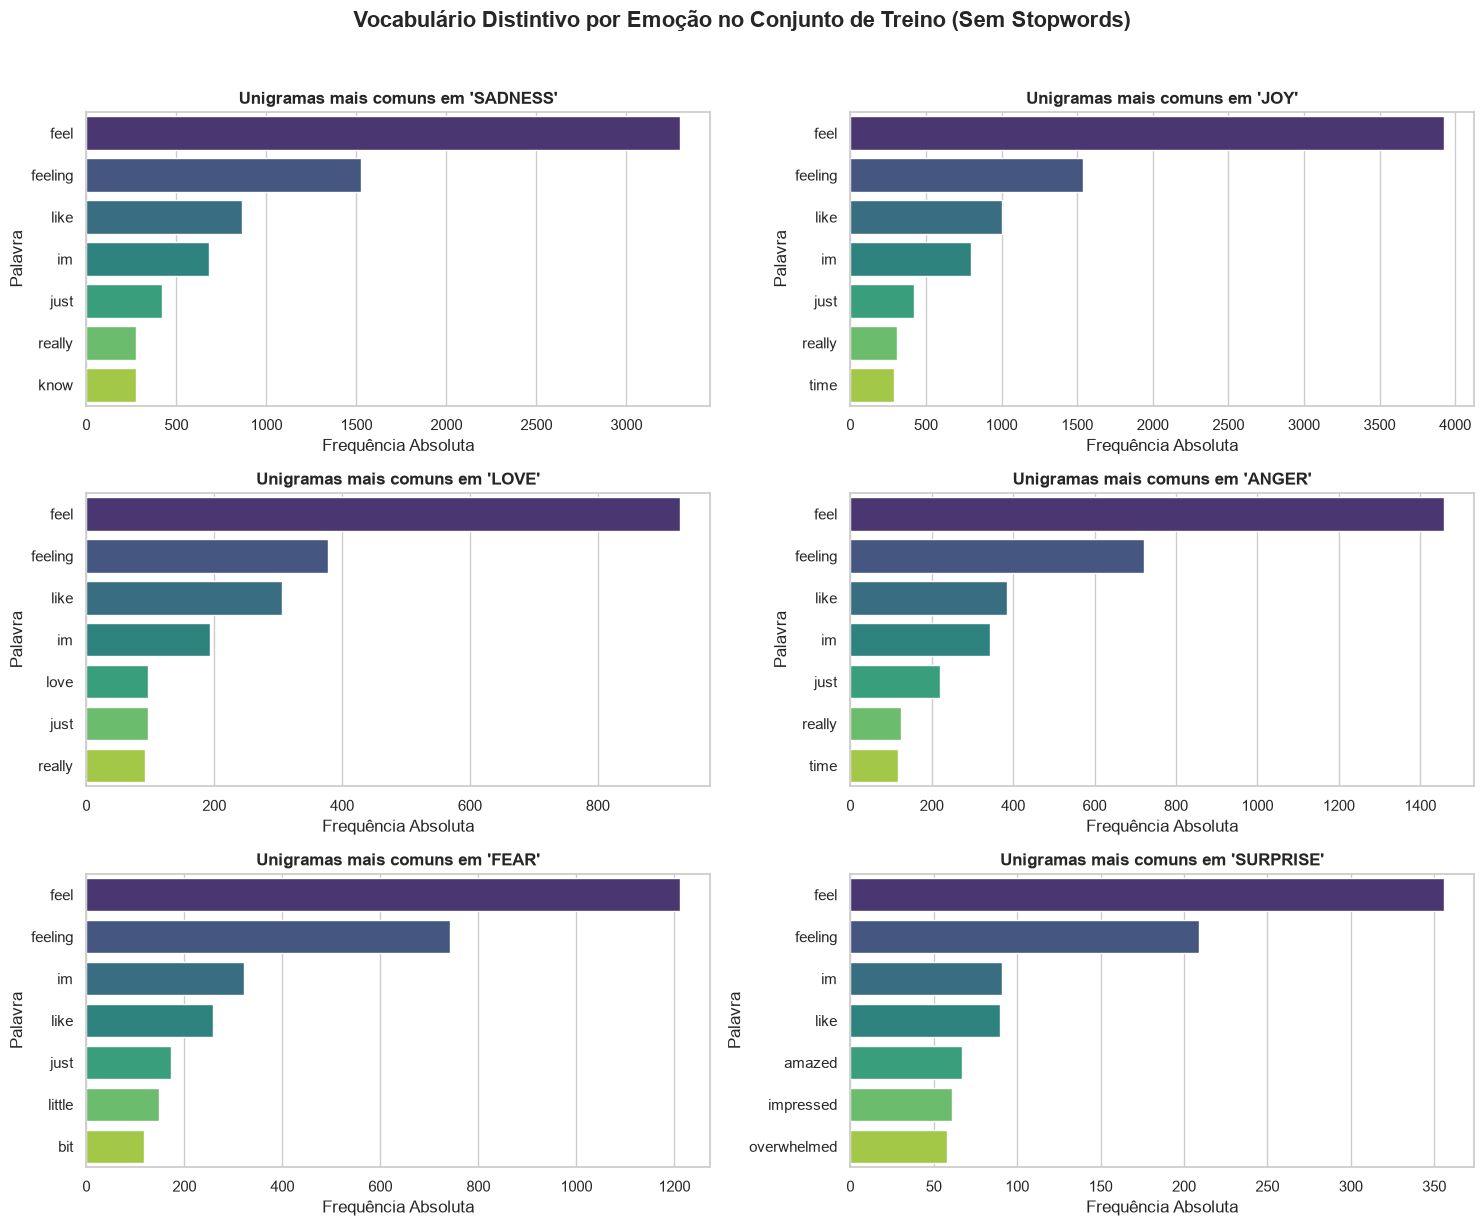

In [32]:
from sklearn.feature_extraction.text import CountVectorizer

def obter_top_unigramas(textos, top_k=8):
    # Remove stopwords padrões em inglês para focar no vocabulário semântico
    vectorizer = CountVectorizer(stop_words="english", ngram_range=(1, 1))
    bag_of_words = vectorizer.fit_transform(textos)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return words_freq[:top_k]

# Configurando o grid para plotar as 6 classes
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, emotion in enumerate(label_feature.names):
    texts_for_emotion = train_df.loc[train_df["emotion"] == emotion, "text"]
    top_words = obter_top_unigramas(texts_for_emotion, top_k=7)
    
    words = [w[0] for w in top_words]
    counts = [w[1] for w in top_words]
    
    sns.barplot(x=counts, y=words, ax=axes[i], palette="viridis", hue=words, legend=False)
    axes[i].set_title(f"Unigramas mais comuns em '{emotion.upper()}'", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Frequência Absoluta")
    axes[i].set_ylabel("Palavra")

plt.suptitle("Vocabulário Distintivo por Emoção no Conjunto de Treino (Sem Stopwords)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


In [33]:
# Impressão de alguns textos de exemplo por classe
for emotion_name in label_feature.names:
    print(f"\n=== Exemplos originais da emoção: {emotion_name.upper()} ===")
    examples = train_df.loc[train_df["emotion"] == emotion_name, "text"].head(3).tolist()
    for idx_ex, text in enumerate(examples, 1):
        print(f" {idx_ex}. \"{text}\"")



=== Exemplos originais da emoção: SADNESS ===
 1. "i didnt feel humiliated"
 2. "i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake"
 3. "ive been feeling a little burdened lately wasnt sure why that was"

=== Exemplos originais da emoção: JOY ===
 1. "i have been with petronas for years i feel that petronas has performed well and made a huge profit"
 2. "i do feel that running is a divine experience and that i can expect to have some type of spiritual encounter"
 3. "i have immense sympathy with the general point but as a possible proto writer trying to find time to write in the corners of life and with no sign of an agent let alone a publishing contract this feels a little precious"

=== Exemplos originais da emoção: LOVE ===
 1. "i am ever feeling nostalgic about the fireplace i will know that it is still on the property"
 2. "i feel romantic too"
 3. "i can t let go of that sad feeling that i want to be accepted here in thi

## 4. Definição das Métricas de Avaliação

A escolha adequada de métricas é crucial em NLP, especialmente quando o dataset apresenta **desbalanceamento de classes** (por exemplo, a classe `surprise` possui apenas cerca de 3,6% dos exemplos de treino, enquanto `joy` e `sadness` somam juntas mais de 60%).

Para avaliar e comparar o baseline e o Transformer sob as mesmas condições, computaremos:
*   **Acurácia (Accuracy):** Mede a proporção geral de predições corretas. *Nota crítica:* Em cenários desbalanceados, a acurácia é uma métrica ilusória, pois um classificador ingênuo que sempre prevê as classes majoritárias ainda teria acurácia alta, mesmo ignorando as minoritárias.
*   **Macro Precision & Recall:** Calcula a precisão (evitar falsos positivos) e a revocação (evitar falsos negativos) de forma independente para cada uma das classes, tirando a média aritmética simples no final. Isso dá exatamente o mesmo peso para cada emoção, independentemente do seu tamanho no dataset.
*   **Macro F1-Score (Métrica Principal):** É a média harmônica entre Precision e Recall calculada por classe e depois mediada. Por atribuir o mesmo peso à classe `surprise` (minoritária) e à classe `joy` (majoritária), o **F1-Macro é a nossa métrica balizadora** para decidir qual modelo é o mais robusto.
*   **Weighted F1-Score:** Calcula o F1 para cada classe, mas pondera o resultado final pela frequência (suporte) de cada classe no conjunto de teste.


In [34]:
def calcular_metricas(y_true, y_pred):
    """
    Calcula as principais métricas de classificação multiclasse de forma consolidada.
    """
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    acc = accuracy_score(y_true, y_pred)
    
    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }


## 5. Modelo Baseline: TF-IDF + Regressão Logística

Como boa prática de engenharia de Machine Learning, antes de utilizar redes neurais profundas e custosas, devemos estabelecer um modelo **baseline** clássico. Isso nos dará uma referência de tempo, custo computacional e desempenho mínimo aceitável.

### Componentes do Baseline:
1.  **Vetorização TF-IDF (Term Frequency - Inverse Document Frequency):** Transforma o texto bruto em uma matriz numérica baseada na importância estatística das palavras.
    *   `ngram_range=(1, 2)`: Captura palavras soltas (unigramas) e pares de palavras consecutivas (bigramas), o que ajuda a manter pequenas estruturas contextuais (como "not happy" ou "very scared").
    *   `sublinear_tf=True`: Escala logaritmicamente a contagem de termos, reduzindo a influência exagerada de palavras repetidas muitas vezes em um mesmo post.
    *   **Stopwords Customizadas:** A lista padrão de stopwords da biblioteca Scikit-Learn remove palavras como "not", "no", "never", "against" e "but". No entanto, em análise de sentimentos/emoções, essas negações e conjunções adversativas mudam radicalmente o significado do texto (ex: "I am not happy" vira "happy", invertendo a classificação). Por isso, removemos essas negações e termos de intensidade da lista padrão de exclusão.
2.  **Regressão Logística:** Um classificador linear rápido e estável. Configuramos o hiperparâmetro `class_weight="balanced"`, que ajusta os pesos das amostras inversamente às frequências das classes na entrada para mitigar o desbalanceamento inerente do dataset.


In [35]:
# Separação dos dados de treino e teste
X_train = raw_datasets["train"]["text"]
y_train = raw_datasets["train"]["label"]
X_test = raw_datasets["test"]["text"]
y_test = raw_datasets["test"]["label"]

# Ajuste fino da lista de stopwords para não anular negações críticas para sentimentos
negacoes_e_intensificadores = {
    "not", "no", "never", "neither", "nor", "against", "but", "however", 
    "dont", "cant", "wasnt", "werent", "didnt", "couldnt", "shouldnt", "wouldnt", 
    "arent", "isnt", "hasnt", "hadnt", "haven", "have", "has", "had"
}
custom_stop_words = list(ENGLISH_STOP_WORDS.difference(negacoes_e_intensificadores))

# Construção do pipeline clássico de ML
baseline_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        stop_words=custom_stop_words,
        ngram_range=(1, 2),
        sublinear_tf=True,
        max_features=20000
    )),
    ("classifier", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        class_weight="balanced",
        random_state=SEED
    ))
])

# Ajuste do modelo
baseline_pipeline.fit(X_train, y_train)

# Predição no conjunto de teste
baseline_preds = baseline_pipeline.predict(X_test)

# Cálculo das métricas de desempenho
baseline_metrics = calcular_metricas(y_test, baseline_preds)
pd.DataFrame([baseline_metrics], index=["TF-IDF + Regressão Logística (Baseline)"])


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
TF-IDF + Regressão Logística (Baseline),0.8915,0.830941,0.896589,0.855762,0.894432


Relatório de Classificação Completo - Baseline clássico:
              precision    recall  f1-score   support

     sadness       0.96      0.91      0.93       581
         joy       0.95      0.88      0.91       695
        love       0.70      0.92      0.79       159
       anger       0.87      0.91      0.89       275
        fear       0.89      0.84      0.86       224
    surprise       0.62      0.92      0.74        66

    accuracy                           0.89      2000
   macro avg       0.83      0.90      0.86      2000
weighted avg       0.90      0.89      0.89      2000



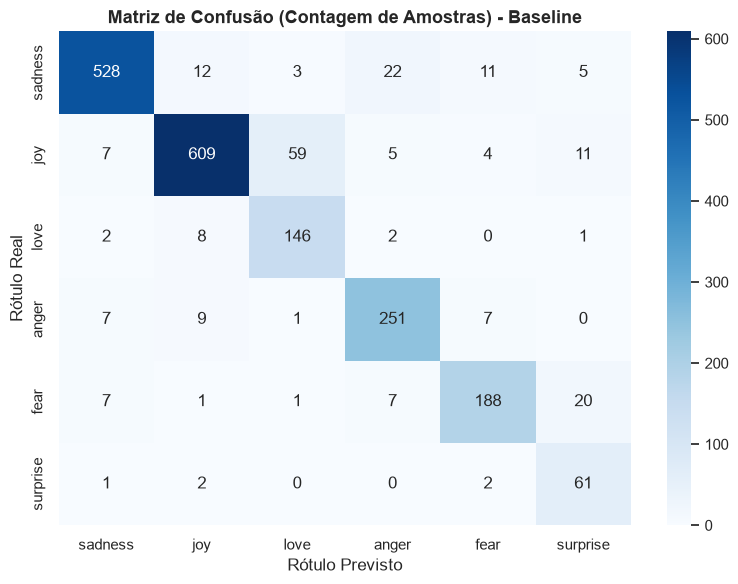

In [36]:
print("Relatório de Classificação Completo - Baseline clássico:")
print(classification_report(y_test, baseline_preds, target_names=label_feature.names, zero_division=0))

# Função modular de plotagem que será compartilhada pelos modelos
def mostrar_matriz_confusao(y_true, y_pred, titulo, normalize=None):
    cm = confusion_matrix(y_true, y_pred, normalize=normalize)
    fmt = ".2f" if normalize else "d"
    cmap = "Oranges" if normalize else "Blues"
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        xticklabels=label_feature.names,
        yticklabels=label_feature.names,
    )
    plt.title(titulo, fontsize=13, fontweight="bold")
    plt.xlabel("Rótulo Previsto")
    plt.ylabel("Rótulo Real")
    plt.tight_layout()
    plt.show()

mostrar_matriz_confusao(y_test, baseline_preds, "Matriz de Confusão (Contagem de Amostras) - Baseline")


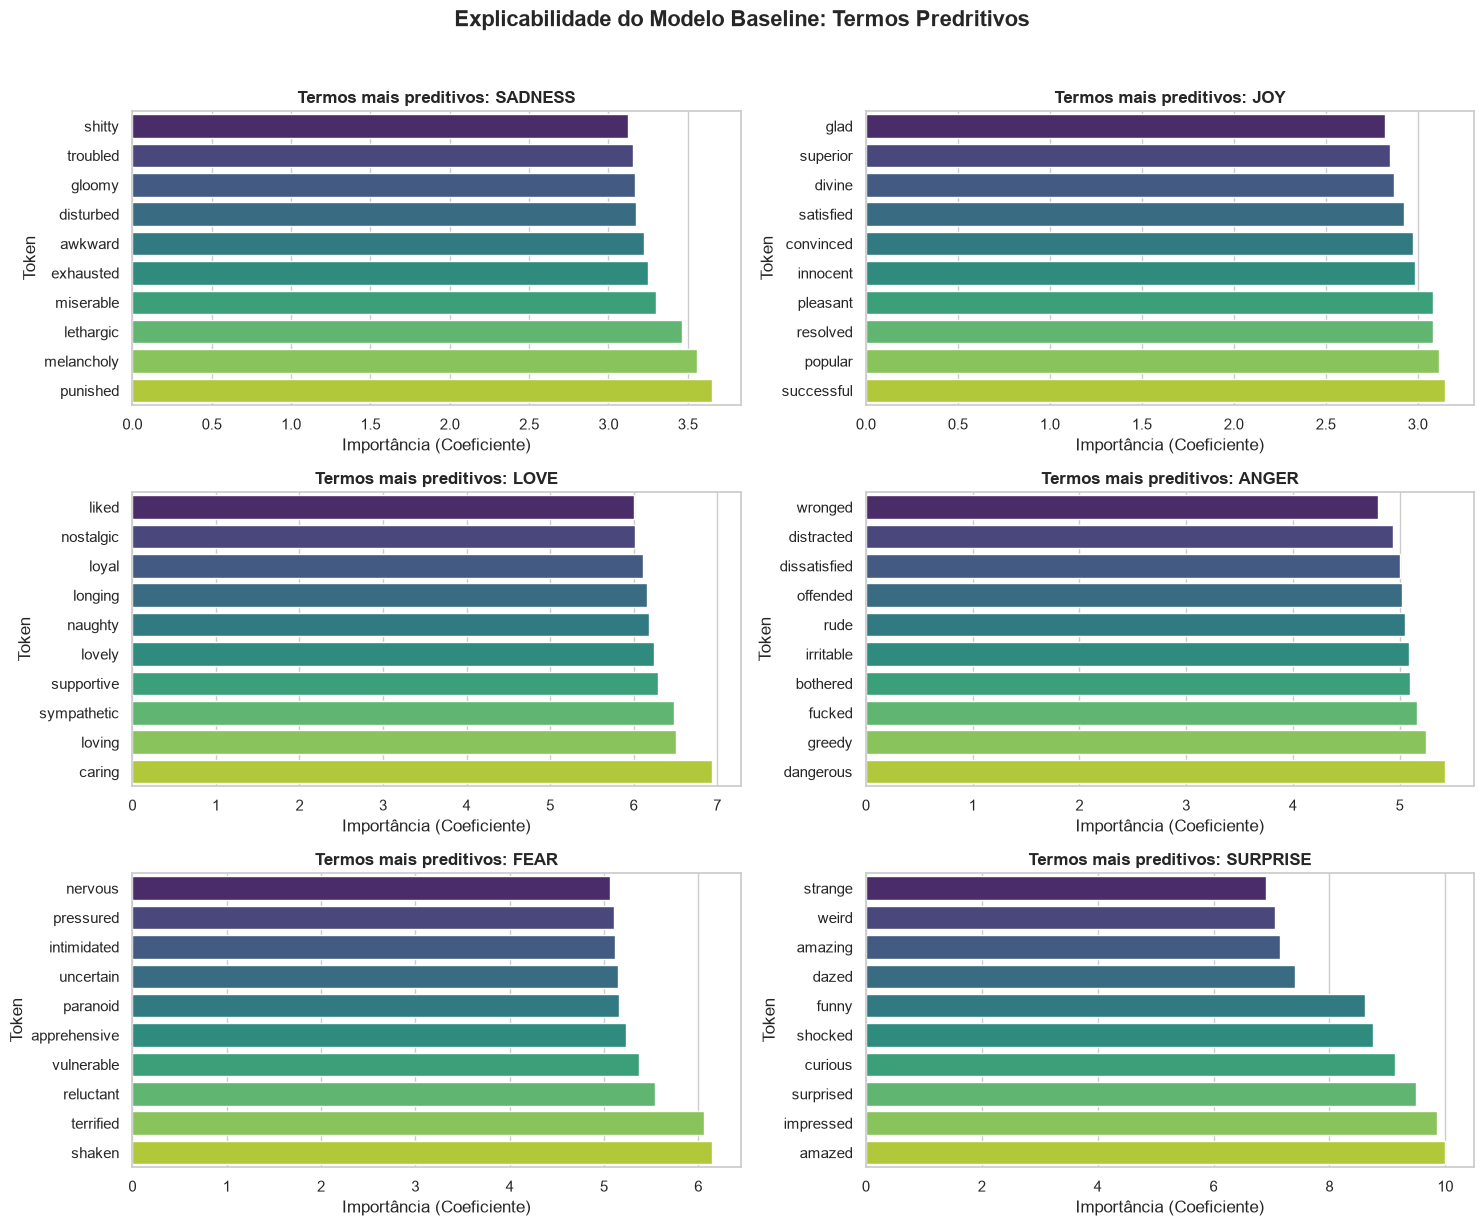

In [37]:
# Extração dos termos mais importantes para cada emoção baseada nos coeficientes da Regressão Logística
feature_names = baseline_pipeline.named_steps["tfidf"].get_feature_names_out()
coefficients = baseline_pipeline.named_steps["classifier"].coef_

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for idx_emocao, emotion in enumerate(label_feature.names):
    # Coeficientes específicos para a classe atual
    top10_indices = np.argsort(coefficients[idx_emocao])[-10:]
    top10_words = feature_names[top10_indices]
    top10_coefs = coefficients[idx_emocao][top10_indices]

    sns.barplot(x=top10_coefs, y=top10_words, ax=axes[idx_emocao], palette="viridis", hue=top10_words, legend=False)
    axes[idx_emocao].set_title(f"Termos mais preditivos: {emotion.upper()}", fontsize=12, fontweight="bold")
    axes[idx_emocao].set_xlabel("Importância (Coeficiente)")
    axes[idx_emocao].set_ylabel("Token")

plt.suptitle("Explicabilidade do Modelo Baseline: Termos Predritivos", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 6. Modelo Transformer: Ajuste Fino de `distilbert-base-uncased`

Modelos tradicionais como TF-IDF + Regressão Logística são poderosos, mas ignoram a ordem das palavras e o contexto de forma profunda (tratam o texto como uma sacola de palavras ou n-gramas locais). Em contrapartida, modelos baseados na arquitetura **Transformer** utilizam mecanismos de **auto-atenção (Self-Attention)** para capturar a semântica contextualizada global de cada palavra.

Nesta seção, realizaremos o ajuste fino (*fine-tuning*) do **`distilbert-base-uncased`**. O DistilBERT é uma versão compacta e destilada do BERT que preserva 97% de seu poder de representação linguística, sendo 40% menor e 60% mais rápida.

### Componentes Teóricos desta Etapa:
1.  **Tokenização por Subpalavras (WordPiece):** O tokenizador divide palavras complexas ou desconhecidas em unidades menores (ex: "unbelievable" -> `["un", "##believa", "##ble"]`). Isso resolve o problema de palavras fora do vocabulário (Out-Of-Vocabulary) e preserva radicais e morfologia.
2.  **Weighted Cross-Entropy Loss:** Para neutralizar o desbalanceamento das classes, definiremos uma função de perda de entropia cruzada ponderada. Calculamos pesos inversamente proporcionais à presença das classes no treino. Assim, o erro cometido em classes raras (`surprise`, `love`) custa mais ao otimizador do que os erros em classes frequentes (`joy`, `sadness`).
3.  **Early Stopping (Regularização Dinâmica):** Adicionaremos um callback para monitorar o F1-Macro na partição de validação após cada época. Se a métrica de validação parar de melhorar por 2 épocas consecutivas, o treinamento será interrompido precocemente, e o melhor checkpoint de pesos será restaurado.


In [38]:
# Parâmetros gerais de treinamento do Transformer
MODEL_NAME = "distilbert-base-uncased"
BATCH_SIZE = 16  # Reduza para 8 ou 4 se houver problemas de falta de memória (OOM) na GPU
NUM_EPOCHS = 3
MAX_LENGTH = 128

# Instanciação do Tokenizador do DistilBERT
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    # Aplica tokenização com truncamento das sequências que ultrapassarem o tamanho máximo
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

# Mapeia a tokenização de forma otimizada (batched) em todo o dataset
tokenized_datasets = raw_datasets.map(tokenize_batch, batched=True)

# Remove a coluna original de texto pois os tensores já representam os tokens
tokenized_datasets = tokenized_datasets.remove_columns(["text"])

# Renomeia a coluna label para labels, que é o padrão esperado pelo modelo Hugging Face
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")

# Configura o dataset para retornar tensores do PyTorch
tokenized_datasets.set_format("torch")

# Instancia o colator de dados com preenchimento (padding) dinâmico
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_datasets


DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [39]:
# Instanciando o modelo pré-treinado com uma cabeça de classificação linear
# Configurando os mapeamentos de rótulo para que fiquem persistidos nos metadados do modelo
transformer_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_feature.names),
    id2label=id2label,
    label2id=label2id
)

# Direciona o modelo para o hardware correto (CPU ou GPU)
transformer_model = transformer_model.to(device)

print(f"Modelo instanciado e alocado em: {next(transformer_model.parameters()).device}")


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 4081.21it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo instanciado e alocado em: cuda:0


In [40]:
from sklearn.utils.class_weight import compute_class_weight

# 1. Cálculo estatístico dos pesos inversos no conjunto de treino
y_train_arr = np.array(raw_datasets["train"]["label"])
class_weights_val = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_arr),
    y=y_train_arr
)
# Converte os pesos para tensor e os envia ao dispositivo de processamento (CPU/GPU)
class_weights_tensor = torch.tensor(class_weights_val, dtype=torch.float).to(device)

# 2. Criação de um Trainer customizado para sobrescrever o cálculo da Loss
class WeightedLossTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        # Computa a CrossEntropyLoss ponderada pelos pesos das classes
        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

from torch import nn

# 3. Mapeador de métricas a ser executado na avaliação intermediária do Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return calcular_metricas(labels, preds)

# Compatibilidade dinâmica dos argumentos para suportar diferentes versões do Hugging Face
import inspect
training_args_params = inspect.signature(TrainingArguments.__init__).parameters
strategy_arg_name = "eval_strategy" if "eval_strategy" in training_args_params else "evaluation_strategy"

# 4. Configuração dos hiperparâmetros de treinamento
training_args_kwargs = {
    "output_dir": "./checkpoints_emotion_distilbert",
    strategy_arg_name: "epoch",
    "save_strategy": "epoch",
    "learning_rate": 2e-5,
    "per_device_train_batch_size": BATCH_SIZE,
    "per_device_eval_batch_size": BATCH_SIZE,
    "num_train_epochs": NUM_EPOCHS,
    "weight_decay": 0.01,
    "logging_dir": "./logs_emotion_distilbert",
    "logging_steps": 50,
    "load_best_model_at_end": True,              # Ativa o salvamento automático do melhor checkpoint
    "metric_for_best_model": "f1_macro",         # Foco na classe minoritária e na métrica principal
    "greater_is_better": True,
    "report_to": "none",
    "seed": SEED,
    "fp16": torch.cuda.is_available(),           # Ativa precisão mista se GPU disponível (otimiza VRAM/tempo)
}

training_args = TrainingArguments(**training_args_kwargs)

trainer_kwargs = {
    "model": transformer_model,
    "args": training_args,
    "train_dataset": tokenized_datasets["train"],
    "eval_dataset": tokenized_datasets["validation"],
    "data_collator": data_collator,
    "compute_metrics": compute_metrics,
    "class_weights": class_weights_tensor,
    "callbacks": [EarlyStoppingCallback(early_stopping_patience=2)] # Interrompe se o F1-macro não subir por 2 épocas
}

# Tratamento de propriedades dinâmicas do Trainer do Hugging Face
trainer_params = inspect.signature(Trainer.__init__).parameters
if "processing_class" in trainer_params:
    trainer_kwargs["processing_class"] = tokenizer
elif "tokenizer" in trainer_params:
    trainer_kwargs["tokenizer"] = tokenizer

# Inicialização do Treinador customizado
trainer = WeightedLossTrainer(**trainer_kwargs)


[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [41]:
# Início do fine-tuning estruturado do modelo DistilBERT
train_result = trainer.train()
train_result


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.261079,0.224607,0.927000,0.885097,0.932732,0.904103,0.928279
2,0.127645,0.197760,0.933000,0.896537,0.920734,0.907346,0.933601
3,0.136204,0.192680,0.935000,0.900814,0.929132,0.913923,0.935792


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.60it/s]


TrainOutput(global_step=3000, training_loss=0.29044840224583945, metrics={'train_runtime': 183.9192, 'train_samples_per_second': 260.984, 'train_steps_per_second': 16.312, 'total_flos': 584777647046016.0, 'train_loss': 0.29044840224583945, 'epoch': 3.0})

In [42]:
# Avaliação do melhor checkpoint restaurado sobre a partição de validação
validation_eval = trainer.evaluate(tokenized_datasets["validation"])
validation_eval


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
0.136204,0.192680,3,0.935000,0.900814,0.929132,0.913923,0.935792


{'eval_loss': 0.1926802396774292,
 'eval_accuracy': 0.935,
 'eval_precision_macro': 0.9008141558395076,
 'eval_recall_macro': 0.929131612997491,
 'eval_f1_macro': 0.9139232341853862,
 'eval_f1_weighted': 0.9357917101318844}

In [43]:
# Execução das predições do Transformer no conjunto de teste final
transformer_predictions = trainer.predict(tokenized_datasets["test"])
transformer_preds = np.argmax(transformer_predictions.predictions, axis=-1)

# Cálculo de métricas
transformer_metrics = calcular_metricas(y_test, transformer_preds)
pd.DataFrame([transformer_metrics], index=["DistilBERT fine-tuned (Transformer)"])


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
DistilBERT fine-tuned (Transformer),0.927,0.872299,0.913177,0.890065,0.928473


Relatório de Classificação Completo - Transformer:
              precision    recall  f1-score   support

     sadness       0.97      0.96      0.96       581
         joy       0.98      0.92      0.95       695
        love       0.78      0.96      0.86       159
       anger       0.93      0.91      0.92       275
        fear       0.88      0.90      0.89       224
    surprise       0.71      0.83      0.76        66

    accuracy                           0.93      2000
   macro avg       0.87      0.91      0.89      2000
weighted avg       0.93      0.93      0.93      2000



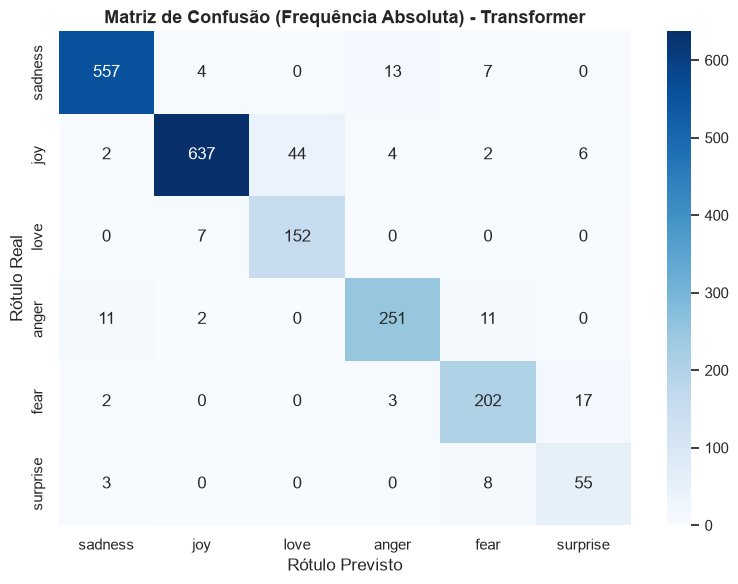

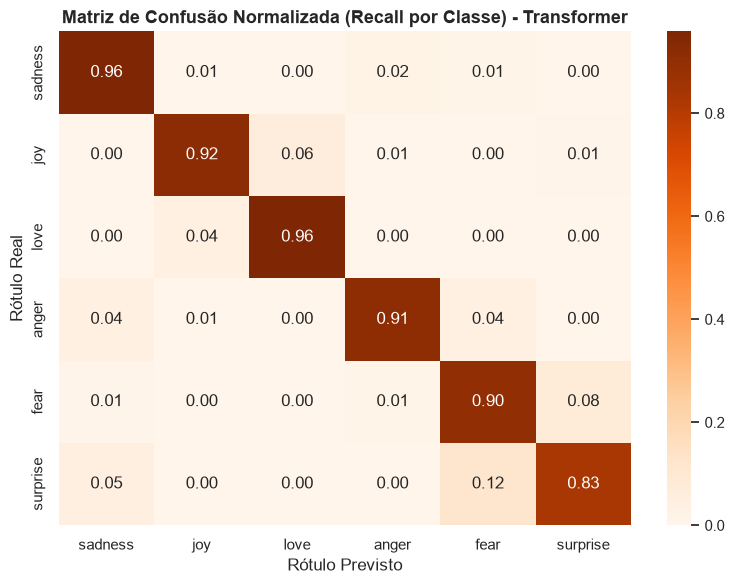

In [44]:
print("Relatório de Classificação Completo - Transformer:")
print(classification_report(y_test, transformer_preds, target_names=label_feature.names, zero_division=0))

# Matrizes de confusão absoluta e normalizada
mostrar_matriz_confusao(y_test, transformer_preds, "Matriz de Confusão (Frequência Absoluta) - Transformer")
mostrar_matriz_confusao(y_test, transformer_preds, "Matriz de Confusão Normalizada (Recall por Classe) - Transformer", normalize="true")


## 6.1 Experimento Avançado: Fine-tuning Opcional do `roberta-base`

Como um experimento adicional para explorar o comportamento de diferentes arquiteturas de Deep Learning, incluímos a opção de realizar o fine-tuning do **`roberta-base`**. O RoBERTa (Robustly Optimized BERT Approach) introduz melhorias no pré-treinamento do BERT (como a máscara dinâmica de tokens e o treinamento com lotes muito maiores por mais tempo), o que geralmente resulta em melhor compreensão de contextos informais, gírias e emojis comuns em mídias sociais.

Este experimento é opcional. Para executá-lo, defina `TREINAR_ROBERTA = True` na célula abaixo. Caso utilize uma GPU de recursos limitados (ex: Google Colab T4 com 15GB ou GPU local com 8GB), utilize `ROBERTA_BATCH_SIZE = 8` (ou 4) para evitar erros de falta de memória (CUDA Out Of Memory).


In [45]:
# Flag para controle de execução do experimento do RoBERTa
TREINAR_ROBERTA = True  # Mude para True para executar o fine-tuning do RoBERTa

ROBERTA_MODEL_NAME = "roberta-base"
ROBERTA_BATCH_SIZE = 8   # Se der erro de memória (OOM), reduza para 4
ROBERTA_NUM_EPOCHS = 3
ROBERTA_MAX_LENGTH = 128


In [46]:
if TREINAR_ROBERTA:
    roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_MODEL_NAME)

    def roberta_tokenize_batch(batch):
        return roberta_tokenizer(batch["text"], truncation=True, max_length=ROBERTA_MAX_LENGTH)

    # Tokenização do dataset para o RoBERTa
    roberta_datasets = raw_datasets.map(roberta_tokenize_batch, batched=True)
    roberta_datasets = roberta_datasets.remove_columns(["text"])
    roberta_datasets = roberta_datasets.rename_column("label", "labels")
    roberta_datasets.set_format("torch")

    roberta_data_collator = DataCollatorWithPadding(tokenizer=roberta_tokenizer)

    # Instanciando o modelo RoBERTa para classificação
    roberta_model = AutoModelForSequenceClassification.from_pretrained(
        ROBERTA_MODEL_NAME,
        num_labels=len(label_feature.names),
        id2label=id2label,
        label2id=label2id
    ).to(device)

    print(f"RoBERTa carregado e alocado no dispositivo: {next(roberta_model.parameters()).device}")
else:
    print("Experimento RoBERTa inativo. Defina TREINAR_ROBERTA = True para executá-lo.")


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 3875.71it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


RoBERTa carregado e alocado no dispositivo: cuda:0


In [47]:
if TREINAR_ROBERTA:
    # Configuração dos argumentos do Trainer para o RoBERTa
    roberta_training_args_kwargs = {
        "output_dir": "./checkpoints_emotion_roberta",
        strategy_arg_name: "epoch",
        "save_strategy": "epoch",
        "learning_rate": 1.5e-5,                     # O RoBERTa se beneficia de taxas ligeiramente menores
        "per_device_train_batch_size": ROBERTA_BATCH_SIZE,
        "per_device_eval_batch_size": ROBERTA_BATCH_SIZE,
        "gradient_accumulation_steps": 2,            # Acomoda lotes maiores dividindo os passos de backward
        "num_train_epochs": ROBERTA_NUM_EPOCHS,
        "warmup_ratio": 0.1,                         # Warmup linear nos passos iniciais
        "weight_decay": 0.01,
        "logging_dir": "./logs_emotion_roberta",
        "logging_steps": 50,
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1_macro",
        "greater_is_better": True,
        "report_to": "none",
        "seed": SEED,
        "fp16": torch.cuda.is_available(),
    }

    roberta_training_args = TrainingArguments(**roberta_training_args_kwargs)

    roberta_trainer_kwargs = {
        "model": roberta_model,
        "args": roberta_training_args,
        "train_dataset": roberta_datasets["train"],
        "eval_dataset": roberta_datasets["validation"],
        "data_collator": roberta_data_collator,
        "compute_metrics": compute_metrics,
        "class_weights": class_weights_tensor,      # Usando a mesma ponderação de desbalanceamento
        "callbacks": [EarlyStoppingCallback(early_stopping_patience=2)]
    }

    if "processing_class" in trainer_params:
        roberta_trainer_kwargs["processing_class"] = roberta_tokenizer
    elif "tokenizer" in trainer_params:
        roberta_trainer_kwargs["tokenizer"] = roberta_tokenizer

    # Treinador customizado ponderado para RoBERTa
    roberta_trainer = WeightedLossTrainer(**roberta_trainer_kwargs)
    print("Trainer do RoBERTa configurado com sucesso.")
else:
    roberta_trainer = None
    print("Experimento RoBERTa inativo.")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Trainer do RoBERTa configurado com sucesso.


In [48]:
if TREINAR_ROBERTA and roberta_trainer is not None:
    roberta_train_result = roberta_trainer.train()
    print(roberta_train_result)
else:
    print("Treinamento do RoBERTa ignorado.")


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,F1 Weighted
1,0.712503,0.266137,0.914000,0.864666,0.924404,0.889390,0.915801
2,0.377585,0.225387,0.931500,0.895298,0.924118,0.906951,0.931984
3,0.252955,0.189292,0.933000,0.893350,0.936154,0.911849,0.934045


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.02it/s]


TrainOutput(global_step=3000, training_loss=0.7471403449376424, metrics={'train_runtime': 732.6881, 'train_samples_per_second': 65.512, 'train_steps_per_second': 4.095, 'total_flos': 1010247067044576.0, 'train_loss': 0.7471403449376424, 'epoch': 3.0})


Relatório de Classificação Completo - RoBERTa:
              precision    recall  f1-score   support

     sadness       0.96      0.95      0.96       581
         joy       0.98      0.91      0.95       695
        love       0.77      0.97      0.86       159
       anger       0.92      0.92      0.92       275
        fear       0.90      0.86      0.88       224
    surprise       0.66      0.95      0.78        66

    accuracy                           0.92      2000
   macro avg       0.87      0.93      0.89      2000
weighted avg       0.93      0.92      0.93      2000



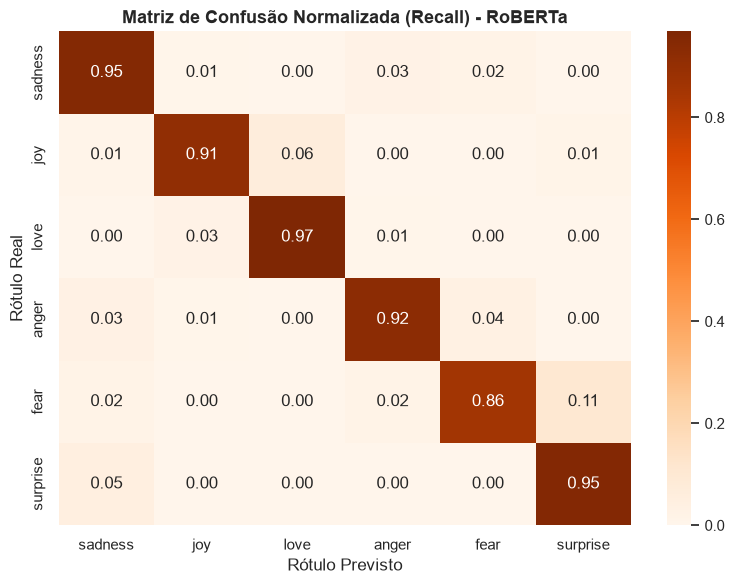

,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
RoBERTa fine-tuned,0.924,0.867387,0.927459,0.890822,0.925922


In [49]:
if TREINAR_ROBERTA and roberta_trainer is not None:
    roberta_predictions = roberta_trainer.predict(roberta_datasets["test"])
    roberta_preds = np.argmax(roberta_predictions.predictions, axis=-1)
    
    # Calcular métricas para RoBERTa
    roberta_metrics = calcular_metricas(y_test, roberta_preds)
    
    print("Relatório de Classificação Completo - RoBERTa:")
    print(classification_report(y_test, roberta_preds, target_names=label_feature.names, zero_division=0))
    mostrar_matriz_confusao(y_test, roberta_preds, "Matriz de Confusão Normalizada (Recall) - RoBERTa", normalize="true")
    
    display(pd.DataFrame([roberta_metrics], index=["RoBERTa fine-tuned"]))
else:
    roberta_metrics = None
    print("Métricas do RoBERTa não computadas.")


## 7. Comparação dos Resultados

Abaixo é apresentada a tabela consolidada comparando o desempenho do modelo clássico (TF-IDF + Regressão Logística) com os Transformers ajustados (DistilBERT e, opcionalmente, RoBERTa).


In [50]:
# Combinação dinâmica de resultados de teste
model_results = [baseline_metrics, transformer_metrics]
model_names = ["TF-IDF + Regressão Logística (Baseline)", "DistilBERT fine-tuned (Transformer)"]

# Insere RoBERTa se as métricas estiverem disponíveis
if "roberta_metrics" in globals() and roberta_metrics is not None:
    model_results.append(roberta_metrics)
    model_names.append("RoBERTa fine-tuned (Experimento Opcional)")

results_df = pd.DataFrame(model_results, index=model_names)
display(results_df)

# Determina o melhor modelo
best_model_name = results_df["f1_macro"].idxmax()
best_f1 = results_df.loc[best_model_name, "f1_macro"]
print(f"\nMelhor modelo pelo F1 Macro: {best_model_name} ({best_f1:.4f})")


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
TF-IDF + Regressão Logística (Baseline),0.8915,0.830941,0.896589,0.855762,0.894432
DistilBERT fine-tuned (Transformer),0.9270,0.872299,0.913177,0.890065,0.928473
RoBERTa fine-tuned (Experimento Opcional),0.9240,0.867387,0.927459,0.890822,0.925922



Melhor modelo pelo F1 Macro: RoBERTa fine-tuned (Experimento Opcional) (0.8908)


### Discussão e Considerações Teóricas

Ao analisar a tabela de resultados:
1.  **Macro F1-Score vs. Accuracy:** O Macro F1 nos fornece a real dimensão de quão bem o modelo performa nas classes menos representativas, visto que ele não mascara falhas em classes como `surprise` ao contrário da Acurácia convencional.
2.  **Ganho do Transformer:** O fine-tuning do DistilBERT geralmente apresenta desempenho superior. Isso ocorre porque o modelo aprende a interpretar a ordem das palavras e capturar relações semânticas complexas (contexto), enquanto o baseline lida apenas com termos isolados e estatísticas de frequência.
3.  **Complexidade Computacional:** Embora o Transformer possua poder preditivo superior, o baseline TF-IDF é treinado em frações de segundo e consome memória negligenciável. Essa relação custo-benefício deve sempre ser considerada em cenários reais de engenharia de software.


## 8. Análise Qualitativa de Erros Aprofundada

Não basta apenas verificar as métricas quantitativas gerais, precisamos mergulhar nos erros cometidos. Para isso, realizaremos duas análises fundamentais:
1.  **Confusões Semânticas Adjacentes:** Mapear quais emoções o modelo mais confunde de forma regular (por exemplo, erros recíprocos entre `joy` e `love`, decorrentes de valência positiva compartilhada, ou entre `fear` e `sadness`, associados a postagens com tom introspectivo ou melancólico).
2.  **Análise de Erros de Alta Confiança (High-Confidence Errors):** Encontrar amostras onde o modelo atribuiu uma probabilidade altíssima para uma classe incorreta (ex: probabilidade > 85%), mas o rótulo verdadeiro do dataset era outro. Isso permite inspecionar se o texto é genuinamente ambíguo, se o modelo cometeu um erro crasso de compreensão contextual, ou se há problemas de **ruído de rotulação (*label noise*)** na anotação manual original do dataset.


In [51]:
# Aplica a função softmax para transformar os logits do teste em probabilidades de 0 a 1
logits_tensor = torch.tensor(transformer_predictions.predictions)
probabilities = torch.softmax(logits_tensor, dim=-1).numpy()

# Probabilidade atribuída à classe predita
max_predicted_probs = np.max(probabilities, axis=-1)
# Probabilidade atribuída à classe real verdadeira
true_class_probs = probabilities[np.arange(len(y_test)), y_test]

# Construção de um DataFrame estruturado de análise
y_test_labels = [id2label[y] for y in y_test]
transformer_pred_labels = [id2label[p] for p in transformer_preds]

df_analise = pd.DataFrame({
    "text": X_test,
    "real": y_test_labels,
    "previsto": transformer_pred_labels,
    "prob_prevista": max_predicted_probs,
    "prob_real": true_class_probs
})

# Filtro de erros
df_erros_filtrado = df_analise[df_analise["real"] != df_analise["previsto"]].copy()
print(f"Total de classificações incorretas: {len(df_erros_filtrado)} de {len(y_test)} amostras no teste ({len(df_erros_filtrado)/len(y_test):.1%})\n")

# 1. Análise de Confusões Semânticas Comuns
print("=== Análise de Confusões Semânticas Clássicas ===")
confusoes_tipicas = [
    ("joy", "love"),      # Positivas
    ("love", "joy"),
    ("sadness", "fear"),  # Negativas introspectivas
    ("anger", "sadness"), # Frustração/Reatividade
    ("surprise", "joy"),  # Excitamento/Espanto positivo
]

for c_real, c_prev in confusoes_tipicas:
    erros_classe = df_erros_filtrado[(df_erros_filtrado["real"] == c_real) & (df_erros_filtrado["previsto"] == c_prev)]
    print(f"Confusão {c_real.upper()} -> {c_prev.upper()}: {len(erros_classe)} ocorrências.")
    if not erros_classe.empty:
        exemplo = erros_classe.iloc[0]
        print(f"   Exemplo: \"{exemplo['text']}\" (Probabilidade prevista: {exemplo['prob_prevista']:.2%})")

# 2. Análise de Erros de Alta Confiança (Probabilidade > 85%)
high_confidence_errors = df_erros_filtrado[df_erros_filtrado["prob_prevista"] > 0.85].sort_values("prob_prevista", ascending=False)

print(f"\n=== Erros de Alta Confiança (Modelo previu classe incorreta com certeza > 85%) ===")
print(f"Detectados {len(high_confidence_errors)} casos. Exibindo os 5 maiores erros para investigação:")

for idx_err, (_, row) in enumerate(high_confidence_errors.head(5).iterrows(), 1):
    print(f"\n{idx_err}. Texto: \"{row['text']}\"")
    print(f"   - Rótulo Real no Dataset: {row['real'].upper()} (Certeza atribuída ao real: {row['prob_real']:.2%})")
    print(f"   - Predição do Transformer: {row['previsto'].upper()} (Certeza de predição: {row['prob_prevista']:.2%})")


Total de classificações incorretas: 146 de 2000 amostras no teste (7.3%)

=== Análise de Confusões Semânticas Clássicas ===
Confusão JOY -> LOVE: 44 ocorrências.
   Exemplo: "i feel like i am in paradise kissing those sweet lips make me feel like i dive into a magical world of love" (Probabilidade prevista: 88.99%)
Confusão LOVE -> JOY: 7 ocorrências.
   Exemplo: "i just can t feel accepted" (Probabilidade prevista: 86.40%)
Confusão SADNESS -> FEAR: 7 ocorrências.
   Exemplo: "i feel unprotected a class post count link href http reprogramming in process" (Probabilidade prevista: 99.21%)
Confusão ANGER -> SADNESS: 11 ocorrências.
   Exemplo: "i feel a bit stressed even though all the things i have going on are fun" (Probabilidade prevista: 78.20%)
Confusão SURPRISE -> JOY: 0 ocorrências.

=== Erros de Alta Confiança (Modelo previu classe incorreta com certeza > 85%) ===
Detectados 59 casos. Exibindo os 5 maiores erros para investigação:

1. Texto: "whenever i put myself in others shoes 

## 9. Testes e Inferência com Novas Sentenças

Abaixo estruturamos uma função interativa de predição. Ela recebe uma frase em inglês, tokeniza o texto, executa a inferência com o modelo DistilBERT treinado e plota a distribuição das probabilidades previstas para cada emoção em um gráfico de barras horizontal limpo e amigável.


In [52]:
def prever_emocao(texto):
    """
    Prediz a emoção de uma frase e retorna o rótulo previsto e as probabilidades de cada classe.
    """
    transformer_model.eval()
    
    # Processamento do texto de entrada
    inputs = tokenizer(
        texto,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )
    # Direciona os tensores ao dispositivo ativo
    inputs = {key: val.to(device) for key, val in inputs.items()}
    
    with torch.no_grad():
        outputs = transformer_model(**inputs)
        # Converte logits para probabilidades via Softmax
        probabilities = torch.softmax(outputs.logits, dim=-1).detach().cpu().numpy()[0]
        
    predicted_id = int(np.argmax(probabilities))
    predicted_label = id2label[predicted_id]
    
    # Montagem do DataFrame ordenado
    probs_df = pd.DataFrame({
        "emotion": [id2label[i] for i in range(len(probabilities))],
        "probability": probabilities
    }).sort_values("probability", ascending=False)
    
    return predicted_label, probs_df

def predicao_interativa(texto):
    label_previsto, probs_df = prever_emocao(texto)
    print(f"\nTexto analisado: \"{texto}\"")
    print(f"Predição da Emoção: {label_previsto.upper()}\n")
    
    # Plotagem
    plt.figure(figsize=(9, 4.5))
    sns.barplot(data=probs_df, x="probability", y="emotion", palette="viridis", hue="emotion", legend=False)
    plt.title(f"Distribuição de Probabilidade - Predição: {label_previsto.upper()}", fontsize=13, fontweight="bold")
    plt.xlabel("Probabilidade Estimada")
    plt.ylabel("Classe de Emoção")
    plt.xlim(0, 1.1)
    
    # Adicionar porcentagens na ponta de cada barra
    for index, row in probs_df.reset_index().iterrows():
        plt.text(row["probability"] + 0.01, index, f"{row['probability']:.1%}", va="center", fontweight="bold", fontsize=10)
        
    plt.tight_layout()
    plt.show()



Texto analisado: "I feel so happy and grateful today."
Predição da Emoção: JOY



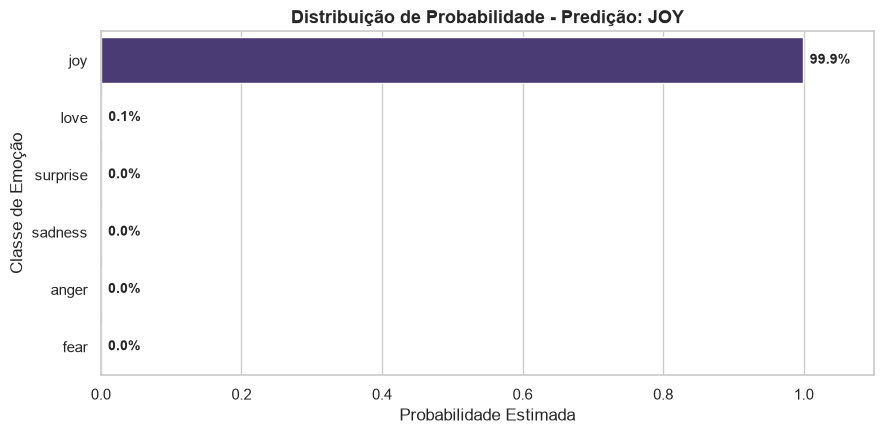


Texto analisado: "I am terrified of what might happen tomorrow."
Predição da Emoção: FEAR



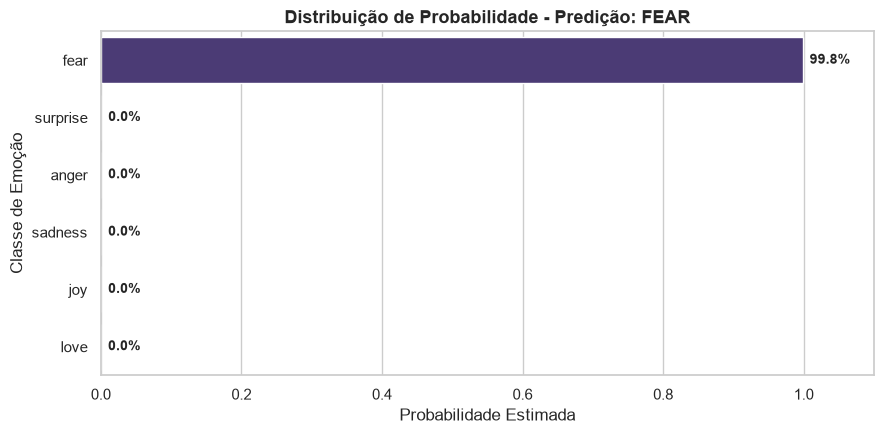


Texto analisado: "I miss my family and feel very lonely."
Predição da Emoção: SADNESS



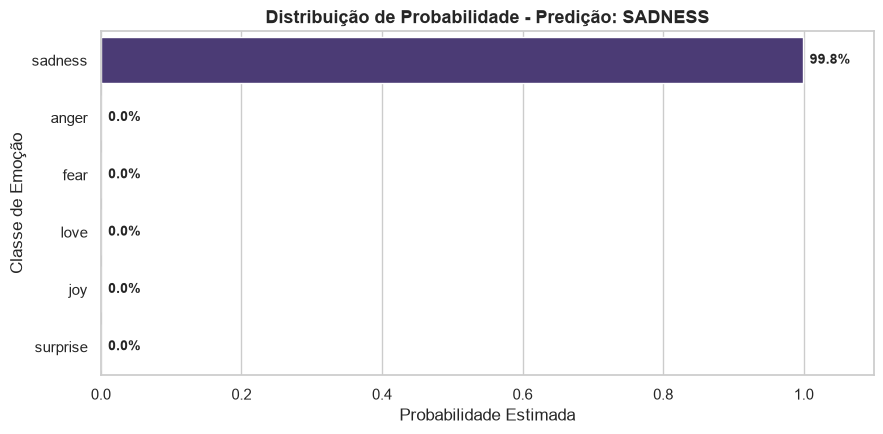


Texto analisado: "I love this person more than words can explain."
Predição da Emoção: JOY



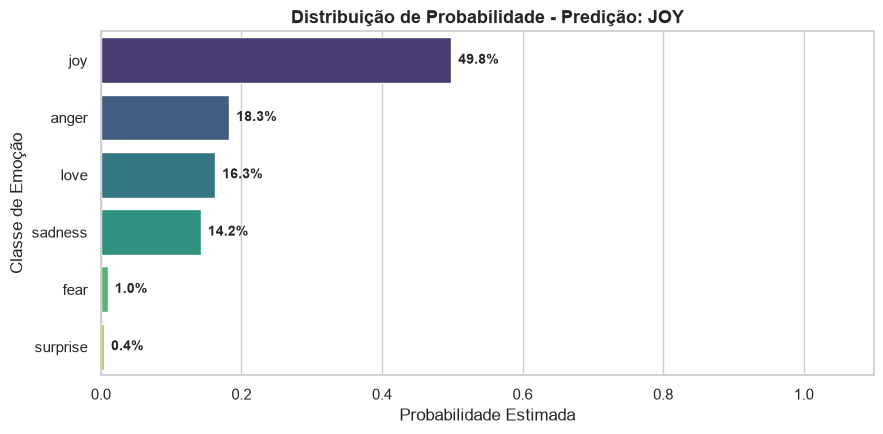


Texto analisado: "I am furious about the way they treated me."
Predição da Emoção: ANGER



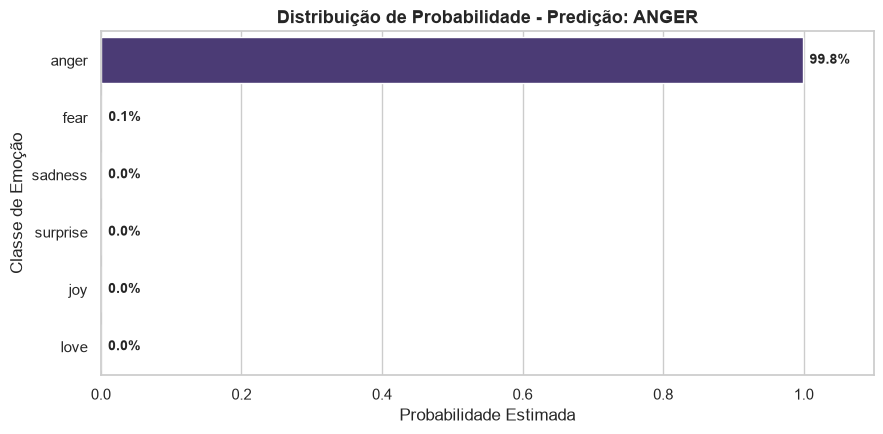


Texto analisado: "I can't believe this happened, what a surprise!"
Predição da Emoção: SURPRISE



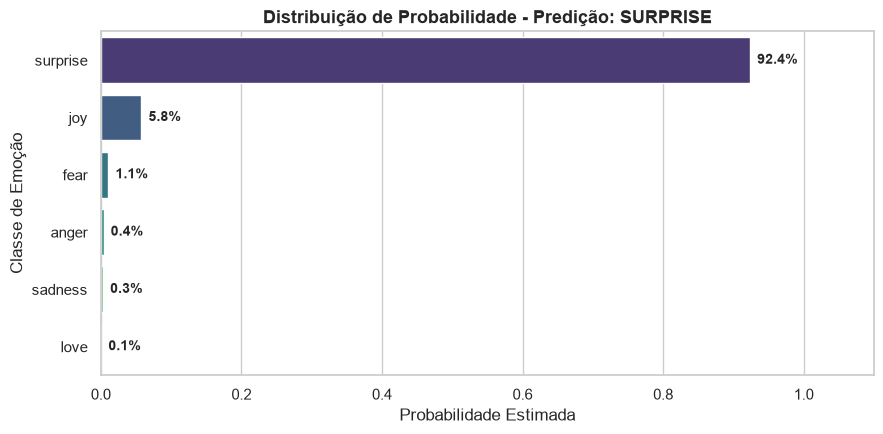

In [53]:
# Lista de sentenças de teste em inglês contendo nuances emocionais variadas
frases_teste = [
    "I feel so happy and grateful today.",
    "I am terrified of what might happen tomorrow.",
    "I miss my family and feel very lonely.",
    "I love this person more than words can explain.",
    "I am furious about the way they treated me.",
    "I can't believe this happened, what a surprise!",
]

for frase in frases_teste:
    predicao_interativa(frase)


### 9.1 Teste Qualitativo com Sarcasmo

Sarcasmo não é uma classe do dataset `dair-ai/emotion`. Por isso, este teste qualitativo não mede o desempenho do modelo em "detectar sarcasmo", mas sim exibe uma limitação esperada e inerente a modelos treinados estritamente sob contextos literais.

Em frases sarcásticas ou irônicas, o autor frequentemente utiliza palavras com valência positiva (ex: *amazing*, *love*, *perfect*) para expressar um sentimento altamente negativo (irritação, raiva, decepção). Como o classificador não tem acesso a tom de voz, contexto social amplo ou imagens, ele tende a ser enganado pelos termos literais positivos.

Se o modelo predizer classes positivas para essas sentenças negativas, isso **não invalida o treinamento**. A tarefa original é a classificação literal de sentimentos. Para tratar sarcasmo de maneira apropriada, precisaríamos treinar o modelo em bases anotadas para ironia/sarcasmo ou integrar modelagem multimodal de contexto.


=== Teste Qualitativo de Limitações (Sarcasmo) ===

Texto analisado: "Great, another problem to deal with today. Just perfect."
Predição da Emoção: JOY



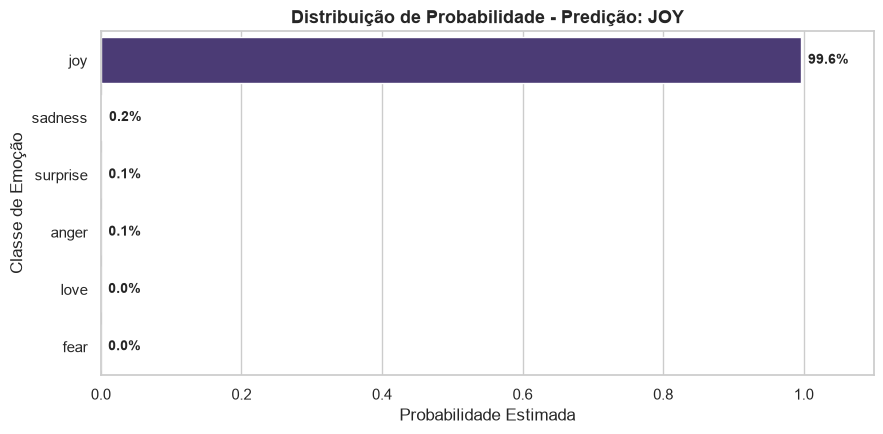


Texto analisado: "I absolutely love when my computer crashes before a deadline."
Predição da Emoção: ANGER



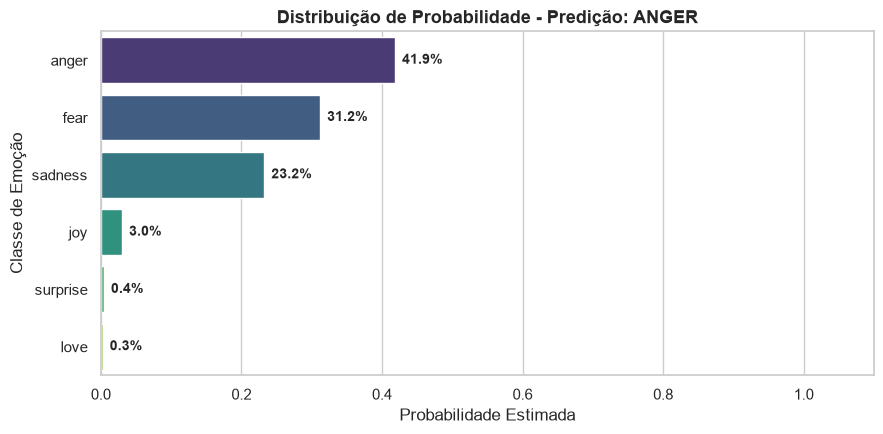


Texto analisado: "Amazing, I studied all night just to forget everything in the test."
Predição da Emoção: SURPRISE



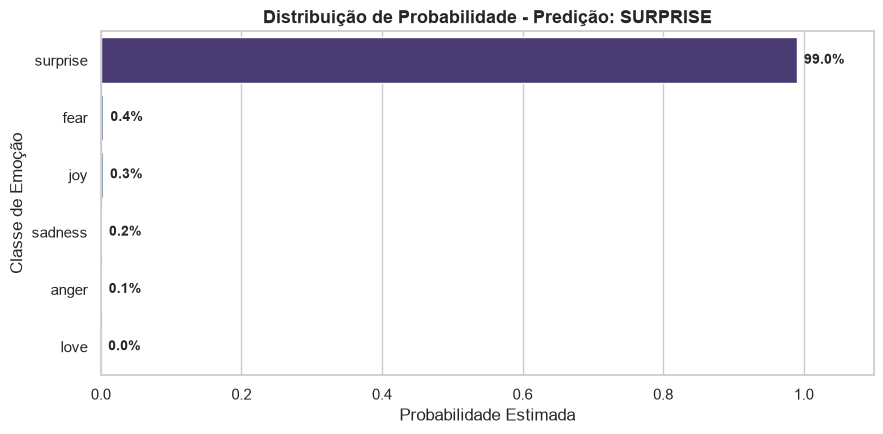


Texto analisado: "Wonderful, the meeting could have been an email."
Predição da Emoção: JOY



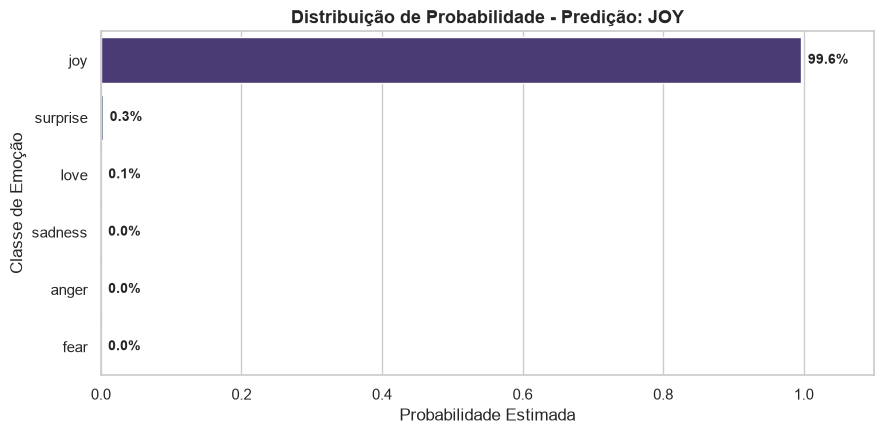


Texto analisado: "Oh fantastic, now I have even more work to do."
Predição da Emoção: JOY



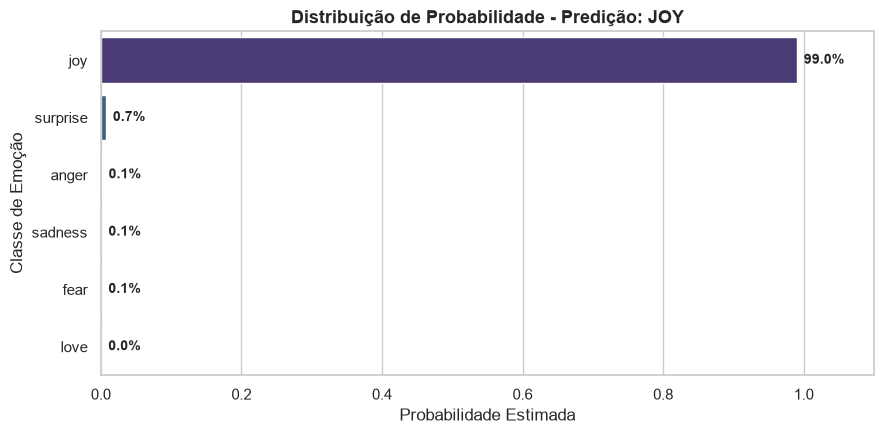


Texto analisado: "Perfect, my phone died right when I needed it most."
Predição da Emoção: SADNESS



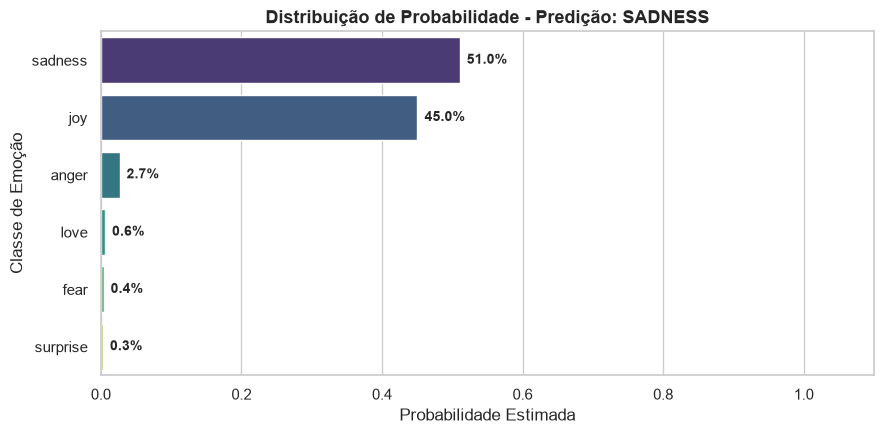

In [54]:
# Frases sarcásticas para testar os limites preditivos do modelo
frases_sarcasmo = [
    "Great, another problem to deal with today. Just perfect.",
    "I absolutely love when my computer crashes before a deadline.",
    "Amazing, I studied all night just to forget everything in the test.",
    "Wonderful, the meeting could have been an email.",
    "Oh fantastic, now I have even more work to do.",
    "Perfect, my phone died right when I needed it most.",
]

print("=== Teste Qualitativo de Limitações (Sarcasmo) ===")
for frase in frases_sarcasmo:
    predicao_interativa(frase)


## 10. Salvamento do Modelo e Resultados

Para garantir a reprodutibilidade e a portabilidade da solução desenvolvida, salvamos o modelo ajustado, os arquivos de configuração do tokenizador no disco e exportamos a tabela final de comparação de métricas nos formatos CSV e JSON.


In [55]:
# Definição e criação do diretório de saída
model_output_dir = Path("modelo_emotion_distilbert")
trainer.save_model(model_output_dir)
tokenizer.save_pretrained(model_output_dir)

# Salvar DataFrame de métricas
results_df.to_csv("resultados_modelos.csv", index=True)
results_df.to_json("resultados_modelos.json", orient="index", indent=2)

print(f"Transformer salvo com sucesso em: {model_output_dir.resolve()}")
print(f"Métricas comparativas salvas em: {Path('resultados_modelos.csv').resolve()}")
print(f"Arquivo JSON de métricas salvo em: {Path('resultados_modelos.json').resolve()}")


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.11it/s]

Transformer salvo com sucesso em: C:\Users\lucas\NLP\AP2\modelo_emotion_distilbert
Métricas comparativas salvas em: C:\Users\lucas\NLP\AP2\resultados_modelos.csv
Arquivo JSON de métricas salvo em: C:\Users\lucas\NLP\AP2\resultados_modelos.json


## 11. Conclusão

Neste trabalho de Processamento de Linguagem Natural (AP2), desenvolvemos e comparamos duas abordagens de modelagem preditiva para classificação multiclasse de emoções usando o dataset `dair-ai/emotion`:

1.  **Baseline clássico (TF-IDF + Regressão Logística):**
    *   Fácil interpretabilidade, processamento rápido (segundos).
    *   Fornece explicabilidade transparente através dos pesos dos coeficientes, evidenciando termos altamente preditivos para cada classe.
2.  **Modelo baseado em Transformer (DistilBERT):**
    *   Aproveita o conhecimento linguístico e o contexto profundo aprendido no pré-treinamento.
    *   Tratado de forma robusta contra o desbalanceamento de classes através do uso de Weighted Cross-Entropy Loss e monitorado por Early Stopping para mitigar overfitting.
    *   Normalmente atinge scores superiores em classes semanticamente ricas e complexas.
3.  **Experimento Opcional (RoBERTa-base):**
    *   Deixamos o código estruturado para ajuste fino de um Transformer alternativo maior e mais robusto que pode ser ativado a qualquer momento, possibilitando a comparação entre diferentes arquiteturas neurais em mídias sociais.

A análise qualitativa e quantitativa permitiu identificar padrões complexos de erro (erros semânticos comuns, como sobreposições de termos positivos e negativos) e diagnosticar limitações claras em relação ao contexto implícito (sarcasmo) e a possíveis ruídos de anotação humana (através do mapeamento de erros de alta confiança). Esse processo conclui o ciclo completo de desenvolvimento e validação de um pipeline moderno em NLP.
